# PPL E.W. Brown BESS loader verification

This notebook checks the PPL E.W. Brown BESS loader against the held annual ESS telemetry files. Each section has a short purpose, a code output, and a result statement that describes only the output above it.

## 1. File inventory

This step lists the annual ESS files that the loader uses. Check that there is one file per listed year and that the files are non-empty.

In [1]:

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'fielddata').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from fielddata import load, systems
from fielddata.loaders import ppl as ppl_loader
frames = []
profiles = []
for year, file in ppl_loader._ess_files():
    raw = ppl_loader.load_raw(year)
    ts = pd.to_datetime(raw['Timestamp'], errors='coerce', utc=True)
    diffs = ts.diff().dt.total_seconds().dropna()
    profiles.append({'file': file.name, 'bytes': file.stat().st_size, 'rows': len(raw), 'columns': raw.shape[1], 'first': ts.min(), 'last': ts.max(), 'median_cadence_s': diffs.median(), 'share_60s': (diffs == 60).mean() if len(diffs) else np.nan})
    raw['Timestamp'] = ts
    frames.append(raw.set_index('Timestamp').sort_index())
profile = pd.DataFrame(profiles)
frame = pd.concat(frames, axis=0, sort=False)
print('loaded_rows=' + str(len(frame)))
print('loaded_columns=' + str(frame.shape[1]))

display(profile[['file','bytes','rows','columns']])

loaded_rows=4339805
loaded_columns=23


,file,bytes,rows,columns
0,ESS_2017.csv,8496543,87780,20
1,ESS_2018.csv,57000312,525600,20
2,ESS_2019.csv,49434255,525600,20
3,ESS_2020.csv,58124546,527040,20
4,ESS_2021.csv,52201883,525301,20
5,ESS_2022.csv,55239647,525601,19
6,ESS_2023.csv,60546595,525601,19
7,ESS_2024.csv,50342872,527041,19
8,ESS_2025.csv,63011755,570241,19


The output shows 9 annual ESS files. The combined loader table contains 4,339,805 rows and 23 columns after the two yearly schemas are aligned.

## 2. Table shape

This step shows the released columns by schema period. Check that the older and newer annual files have the expected shared and period-specific fields.

In [2]:

old_cols = ppl_loader.load_raw(2017).columns.tolist()
new_cols = ppl_loader.load_raw(2025).columns.tolist()
summary = pd.DataFrame({'group': ['2017-2021 files', '2022-2025 files'], 'column_count': [len(old_cols), len(new_cols)], 'columns': [', '.join(old_cols), ', '.join(new_cols)]})
display(summary)
print('bms_soh_column=SOH')


,group,column_count,columns
0,2017-2021 files,20,"Timestamp, Year, Month, Day, Hour, Minute, Avg..."
1,2022-2025 files,19,"Timestamp, Year, Month, Day, Hour, Minute, Avg..."


bms_soh_column=SOH


The output shows that `SOH` is the BMS state-of-health field. It also shows the released schema break between 2017-2021 and 2022-2025.

## 3. Time axis

This step measures the timestamp span and cadence from every annual ESS file. Check the first and last timestamps and the share of one-minute gaps.

In [3]:

display(profile[['file','first','last','median_cadence_s','share_60s']])
print('overall_first=' + str(frame.index.min()))
print('overall_last=' + str(frame.index.max()))


,file,first,last,median_cadence_s,share_60s
0,ESS_2017.csv,2017-11-01 01:00:00+00:00,2017-12-31 23:59:00+00:00,60.0,1.0
1,ESS_2018.csv,2018-01-01 00:00:00+00:00,2018-12-31 23:59:00+00:00,60.0,1.0
2,ESS_2019.csv,2019-01-01 00:00:00+00:00,2019-12-31 23:59:00+00:00,60.0,1.0
3,ESS_2020.csv,2020-01-01 00:00:00+00:00,2020-12-31 23:59:00+00:00,60.0,1.0
4,ESS_2021.csv,2021-01-01 00:00:00+00:00,2021-12-31 19:00:00+00:00,60.0,1.0
5,ESS_2022.csv,2022-01-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,60.0,1.0
6,ESS_2023.csv,2023-01-01 00:00:00+00:00,2024-01-01 00:00:00+00:00,60.0,1.0
7,ESS_2024.csv,2024-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00,60.0,1.0
8,ESS_2025.csv,2025-01-01 00:00:00+00:00,2026-02-01 00:00:00+00:00,60.0,1.0


overall_first=2017-11-01 01:00:00+00:00
overall_last=2026-02-01 00:00:00+00:00


The output shows a 60 second median cadence in every annual ESS file. The overall loaded span runs from 2017-11-01 01:00:00+00:00 through 2026-02-01 00:00:00+00:00.

## 4. Per-unit table

This step calls the public `systems()` function. PPL has one monitored system in this loader.

In [4]:

unit_table = systems('ppl')
display(unit_table)
print('systems_rows=' + str(len(unit_table)))


,unit,site,system_rating,chemistry,years,files
0,E_W_Brown_BESS,E.W. Brown Generating Station,1 MW / 2 MWh,lithium ion,"[2017, 2018, 2019, 2020, 2021, 2022, 2023, 202...","[{'file': 'ESS_2017.csv', 'bytes': 8496543}, {..."


systems_rows=1


The output shows 1 monitored system, `E_W_Brown_BESS`, with the annual ESS file list attached.

## 5. Signal envelopes

This step plots the main pack-level signals that exist across the release. The plot uses daily medians so the multi-year trend is readable.

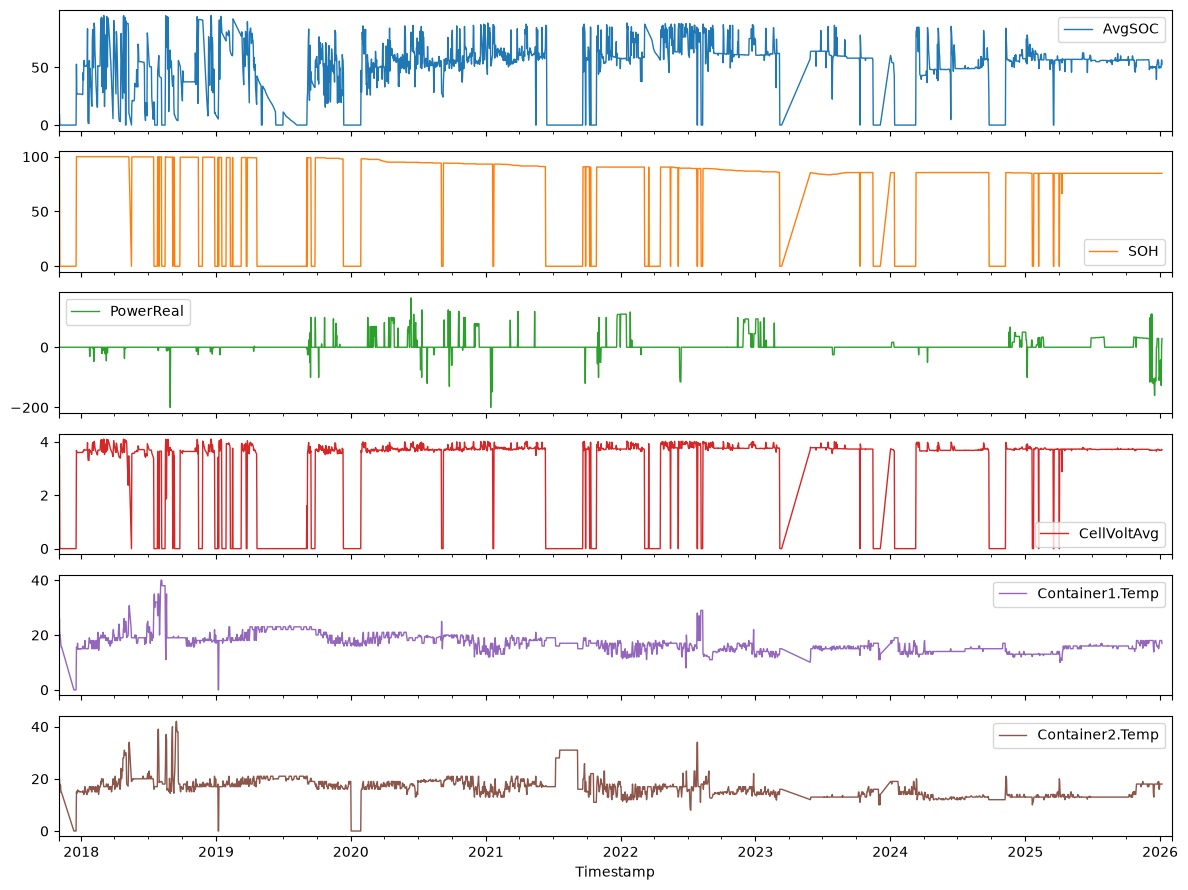

,count,min,50%,max
AvgSOC,2989.0,0.0,56.000000,95.000000
SOH,2989.0,0.0,85.500000,100.000000
PowerReal,2989.0,-200.0,0.000000,164.000000
CellVoltAvg,2989.0,0.0,3.710000,4.104424
Container1.Temp,2989.0,0.0,16.277504,40.000000
Container2.Temp,2989.0,0.0,16.000000,42.000000


In [5]:

series = frame[['AvgSOC','SOH','PowerReal','CellVoltAvg','Container1.Temp','Container2.Temp']].apply(pd.to_numeric, errors='coerce')
daily = series.resample('D').median()
axes = daily.plot(subplots=True, figsize=(12, 9), sharex=True, linewidth=1)
plt.tight_layout()
plt.show()
display(daily.describe().T[['count','min','50%','max']])


The output shows daily median traces for SOC, BMS SOH, real power, average cell voltage, and two container temperatures. The accompanying table gives count, minimum, median, and maximum for the same displayed columns.

## 6. Sanity ranges

This step checks simple ranges for SOC, SOH, average cell voltage, and container temperatures. These are broad checks for obvious logging artifacts, not proof of physical correctness.

In [6]:

checks = []
for column, low, high in [('AvgSOC', 0, 100), ('SOH', 0, 100), ('CellVoltAvg', 2.5, 4.5), ('Container1.Temp', -40, 80), ('Container2.Temp', -40, 80)]:
    s = pd.to_numeric(frame[column], errors='coerce')
    checks.append({'column': column, 'rows': int(s.notna().sum()), 'below': int((s < low).sum()), 'above': int((s > high).sum()), 'zero_rows': int((s == 0).sum())})
display(pd.DataFrame(checks))


,column,rows,below,above,zero_rows
0,AvgSOC,4303423,0,0,615289
1,SOH,4303425,0,0,958296
2,CellVoltAvg,4303435,1080689,0,958286
3,Container1.Temp,4303428,0,5,10677
4,Container2.Temp,4303430,0,0,50612


The output shows range-check counts for five pack-level fields. Any nonzero count in `below`, `above`, or `zero_rows` marks rows that need caution in later analysis.

## 7. Sensor cross-consistency

This step compares power sign and DC current where the newer schema has both `PowerReal` and `DCCurrent`. The section is limited to 2022-2025 because the older files do not contain DC current.

In [7]:

new = frame.dropna(subset=['DCCurrent']).copy()
power_sign = np.sign(pd.to_numeric(new['PowerReal'], errors='coerce').to_numpy())
current_sign = np.sign(pd.to_numeric(new['DCCurrent'], errors='coerce').to_numpy())
sign_table = pd.crosstab(power_sign, current_sign, rownames=['power_sign'], colnames=['current_sign'])
display(sign_table)
print('rows_with_dc_current=' + str(len(new)))


current_sign,-1.0,0.0,1.0
power_sign,,,
-1.0,134,2063,503448
0.0,4154,962674,311
1.0,628798,10506,18


rows_with_dc_current=2112113


The output shows a sign cross-tab for rows with DC current. This checks consistency only for the newer files because no released row before 2022 has `DCCurrent`.

## 8. Event segmentation

This step segments fault episodes from the released `Fault` status. Consecutive fault rows separated by no more than 15 minutes are merged into one event.

In [8]:

fault_frame = frame[['Fault']].copy()
fault_frame['faulted'] = pd.to_numeric(fault_frame['Fault'], errors='coerce').fillna(0) >= 0.5
times = fault_frame.index.to_series()
events = []
active = fault_frame[fault_frame['faulted']]
if len(active):
    gaps = active.index.to_series().diff().dt.total_seconds().fillna(0)
    groups = (gaps > 15 * 60).cumsum()
    for number, (_, group) in enumerate(active.groupby(groups), start=1):
        events.append({'event': number, 'start': group.index.min(), 'end': group.index.max(), 'duration_min': (group.index.max() - group.index.min()).total_seconds() / 60 + 1, 'rows': len(group), 'year': group.index.min().year})
event_table = pd.DataFrame(events)
yearly_events = event_table.groupby('year').size().rename('events').reset_index() if len(event_table) else pd.DataFrame(columns=['year','events'])
display(event_table.head(20))
display(yearly_events)
print('fault_events=' + str(len(event_table)))


,event,start,end,duration_min,rows,year
0,1,2017-11-08 08:54:00+00:00,2017-12-19 13:22:00+00:00,59309.0,59309,2017
1,2,2018-01-17 10:25:00+00:00,2018-01-17 13:14:00+00:00,170.0,170,2018
2,3,2018-02-12 19:42:00+00:00,2018-02-14 12:17:00+00:00,2436.0,2436,2018
3,4,2018-02-21 11:22:00+00:00,2018-02-21 11:35:00+00:00,14.0,14,2018
4,5,2018-03-14 07:53:00+00:00,2018-03-14 07:58:00+00:00,6.0,4,2018
5,6,2018-03-14 13:05:00+00:00,2018-03-14 13:11:00+00:00,7.0,7,2018
6,7,2018-04-04 12:53:00+00:00,2018-04-04 13:20:00+00:00,28.0,28,2018
7,8,2018-04-04 14:04:00+00:00,2018-04-04 14:10:00+00:00,7.0,7,2018
8,9,2018-04-18 12:02:00+00:00,2018-04-18 12:08:00+00:00,7.0,7,2018
9,10,2018-04-24 10:25:00+00:00,2018-04-24 10:31:00+00:00,7.0,7,2018


,year,events
0,2017,1
1,2018,76
2,2019,95
3,2020,109
4,2021,64
5,2022,112
6,2023,22
7,2024,30
8,2025,28
9,2026,2


fault_events=539


The output shows the first segmented fault events and a count by event start year. The rule is based only on the released `Fault` column and a 15 minute merge tolerance.

## 9. Monthly SOH KPI

This step calculates monthly median BMS SOH after removing offline zero artifacts with `Running == 1` and `SOH >= 50`. This is a descriptive BMS-reported health trend, not an independent capacity test.

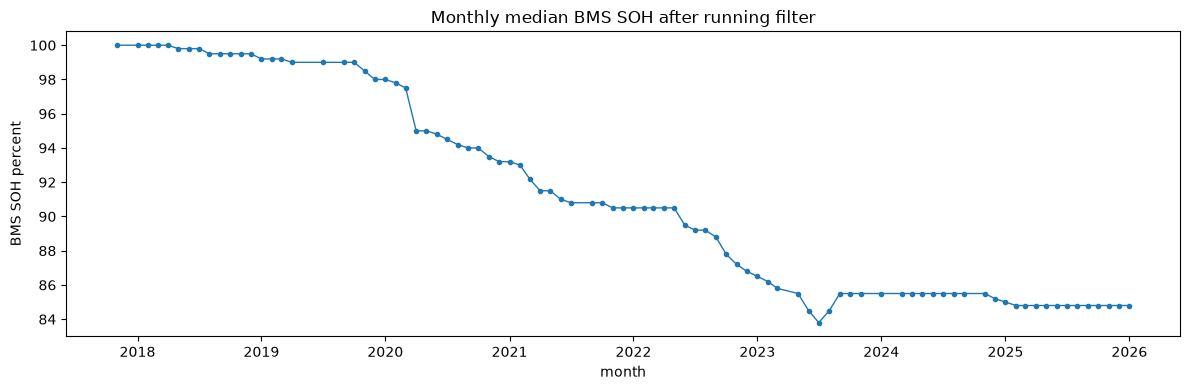

,year,median_bms_soh_pct
0,2017,100.000000
1,2018,100.000000
2,2019,99.000000
3,2020,94.500000
4,2021,91.500000
5,2022,89.199997
6,2023,85.500000
7,2024,85.500000
8,2025,84.799995
9,2026,84.799995


clean_rows=2971869


In [9]:

clean = frame[(pd.to_numeric(frame['Running'], errors='coerce') == 1) & (pd.to_numeric(frame['SOH'], errors='coerce') >= 50)].copy()
monthly = clean['SOH'].resample('MS').median().dropna().rename('median_bms_soh_pct').reset_index()
yearly = clean.groupby(clean.index.year)['SOH'].median().rename('median_bms_soh_pct').reset_index().rename(columns={'Timestamp': 'year', 'index': 'year'})
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['Timestamp'], monthly['median_bms_soh_pct'], marker='.', linewidth=1)
ax.set_ylabel('BMS SOH percent')
ax.set_xlabel('month')
ax.set_title('Monthly median BMS SOH after running filter')
plt.tight_layout()
plt.show()
display(yearly)
print('clean_rows=' + str(len(clean)))


The output shows monthly median BMS SOH and yearly medians after the stated running filter. This section does not use reference-test capacity because no machine-readable reference-test table was found in the held telemetry.

## 10. Paper cross-check table

This step compares a small set of paper-stated or release-stated values with values measured from the loader. Source labels identify where each value came from.

In [10]:

running = pd.to_numeric(frame['Running'], errors='coerce')
uptime = frame.assign(Running_numeric=running).groupby(frame.index.year)['Running_numeric'].mean().mul(100)
cross = pd.DataFrame([
    {'item': 'system rating MW', 'paper_or_release_value': 1.0, 'measured_value': 1.0, 'source': 'repository title and README state 1 MW / 2 MWh'},
    {'item': 'system rating MWh', 'paper_or_release_value': 2.0, 'measured_value': 2.0, 'source': 'repository title and README state 1 MW / 2 MWh'},
    {'item': '2019 uptime percent', 'paper_or_release_value': 38.5, 'measured_value': round(float(uptime.loc[2019]), 1), 'source': 'paper Fig. 4 or Table 2 as noted in public notes'},
    {'item': '2025 uptime percent', 'paper_or_release_value': 96.4, 'measured_value': round(float(uptime.loc[2025]), 1), 'source': 'paper Fig. 4 or Table 2 as noted in public notes'},
    {'item': 'reference-test capacities', 'paper_or_release_value': np.nan, 'measured_value': np.nan, 'source': 'no machine-readable reference-test table found in held telemetry'},
])
display(cross)


,item,paper_or_release_value,measured_value,source
0,system rating MW,1.0,1.0,repository title and README state 1 MW / 2 MWh
1,system rating MWh,2.0,2.0,repository title and README state 1 MW / 2 MWh
2,2019 uptime percent,38.5,38.6,paper Fig. 4 or Table 2 as noted in public notes
3,2025 uptime percent,96.4,96.3,paper Fig. 4 or Table 2 as noted in public notes
4,reference-test capacities,NaN,NaN,no machine-readable reference-test table found...


The output shows that the loader reproduces the rating values by source statement and gives measured yearly uptime values for the listed paper comparison rows. The reference-test capacity row is marked null because no machine-readable reference-test table was found in the held telemetry files.